In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
import seaborn as sns

# 1. 데이터 로드
df_store = pd.read_csv('dataset/store_seoul.csv', encoding='utf-8')
df_infra = pd.read_csv('dataset/infra_seoul.csv', encoding='euc-kr')
df_bridge = pd.read_csv('dataset/bridge_seoul.csv', encoding='euc-kr')
df_close = pd.read_csv('dataset/close_seoul.csv', encoding='euc-kr')

# 폰트지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

# 2. 카페 데이터 추출 및 인프라 수치 숫자화
target_upjong = ['카페', '빵/도넛']
df_cafe_group = df_store[df_store['상권업종소분류명'].isin(target_upjong)].copy()
df_close = df_close[df_close['서비스_업종_코드_명'].str.contains('커피-음료', na=False)].copy()

df_close = df_close[[
    '행정동_코드_명',
    '폐업_률',
    '폐업_점포_수',
    '점포_수'
]]
df_close = df_close.groupby('행정동_코드_명').agg({
    '폐업_률': 'mean',
    '폐업_점포_수': 'mean',
    '점포_수': 'mean'
}).reset_index()
df_infra['집객시설_수'] = pd.to_numeric(df_infra['집객시설_수'], errors='coerce')

# 정밀 키 (숫자 포함)
# 구 + 동 조합에서 마침표, 공백, '제', '?'를 제거한 정밀 키 생성
def make_precise_key(gu, dong):
    if pd.isna(gu) or pd.isna(dong): return ""
    s = str(gu) + str(dong)
    s = re.sub(r'제|\s+|\.', '', s)
    s = s.replace('?', '')
    return s

# 단순 키 (숫자 제거)
# 정밀 키에서 숫자까지 제거한 단순 키 생성(1, 2동 통합용)
def make_simple_key(gu, dong):
    if pd.isna(gu) or pd.isna(dong): return ""
    return re.sub(r'제|\d|\s+|\.', '', str(gu) + str(dong))

# 3. 인프라 마스터 테이블 생성(Infrastructure Mapping)
# df_bridge 데이터 기준으로 매칭용 키 생성
df_bridge['정밀키'] = df_bridge.apply(lambda x: make_precise_key(x['자치구_코드_명'], x['행정동_코드_명']), axis=1)
df_bridge['단순키'] = df_bridge.apply(lambda x: make_simple_key(x['자치구_코드_명'], x['행정동_코드_명']), axis=1)

# 상권 코드와 키를 연결하는 맵 생성
infra_map = df_bridge[['상권배후지_구분_코드', '정밀키', '단순키']].drop_duplicates()

# 인프라 데이터(df_infra)에 브릿지의 키 합치기
# df_infra_mapped에는 '정밀키'와 '단순키' 컬럼 생성
df_infra_mapped = pd.merge(df_infra, infra_map, left_on='상권배후지_코드', right_on='상권배후지_구분_코드', how='left')

# 키별 집객시설 수 평균(정밀/단순 2종류)
infra_precise = df_infra_mapped.groupby('정밀키').agg({
    '집객시설_수': 'mean',
    '지하철_역_수': 'mean',
    '버스_정거장_수': 'mean'
}).reset_index()
infra_simple = df_infra_mapped.groupby('단순키').agg({
    '집객시설_수': 'mean',
    '지하철_역_수': 'mean',
    '버스_정거장_수': 'mean'
}).reset_index()

# 4. 카페 데이터 매칭 및 보정(Waterfall Merge)
# 수동 매핑
exception_mapping = {
    "종로구종로1.2.3.4가동": "종로구종로1234가동",
    "종로구종로5.6가동": "종로구종로56가동"
}
# 카페 데이터 키 생성 시 예외 반영
def final_clean_key(gu, dong):
    key = make_precise_key(gu, dong)
    return exception_mapping.get(key, key)
# 카페 데이터에 키 적용
df_cafe_group['정밀키'] = df_cafe_group.apply(lambda x: final_clean_key(x['시군구명'], x['행정동명']), axis=1) 
df_cafe_group['단순키'] = df_cafe_group.apply(lambda x: make_simple_key(x['시군구명'], x['행정동명']), axis=1)

# 1단계: 정밀키 매칭
df_final = pd.merge(df_cafe_group, infra_precise, on='정밀키', how='left')


# 2단계: NaN인 애들만 단순키로 다시 시도
infra_simple_dict = infra_simple.set_index('단순키').to_dict('index')

mask = df_final['집객시설_수'].isna()

df_final.loc[mask, ['집객시설_수', '지하철_역_수', '버스_정거장_수']] = \
    df_final.loc[mask, '단순키'].apply(
        lambda x: pd.Series(infra_simple_dict.get(x, {}))
    )
# 3단계: 데이터 부재 지역 구 평균값으로 최종 보정
for col in ['집객시설_수', '지하철_역_수', '버스_정거장_수']:
    gu_avg = df_final[df_final[col] > 0].groupby('시군구명')[col].mean()
    df_final[col] = df_final[col].fillna(df_final['시군구명'].map(gu_avg))

df_cafe_count = df_cafe_group.groupby(['시군구명', '행정동명']).size().reset_index(name='카페_수')
df_infra_dong = df_final[
    ['시군구명', '행정동명', '집객시설_수', '지하철_역_수', '버스_정거장_수']
].drop_duplicates()

df_dong = pd.merge(
    df_cafe_count,
    df_infra_dong,
    on=['시군구명', '행정동명'],
    how='left'
)
# 컬럼명 맞추기
df_dong_merged = pd.merge(
    df_dong,
    df_close,
    left_on='행정동명',
    right_on='행정동_코드_명',
    how='left'
)

# 불필요 컬럼 제거
df_dong_merged = df_dong_merged.drop(columns=['행정동_코드_명'])
df_dong_merged = df_dong_merged.dropna(subset=['폐업_률'])

# 결측 확인
print("NaN 확인:\n", df_dong_merged.isnull().sum())
df_dong_merged = df_dong_merged.dropna(subset=['집객시설_수', '폐업_률'])

df_dong_merged['카페밀도지수'] = df_dong_merged['카페_수'] / (df_dong_merged['집객시설_수'] + 1)
df_dong_merged['유사업종비율'] = df_dong_merged['카페_수'] / (df_dong_merged['점포_수'] + 1)
df_dong_merged['폐업밀도'] = df_dong_merged['폐업_점포_수'] / (df_dong_merged['집객시설_수'] + 1)

df_dong_merged = df_dong_merged[
    (df_dong_merged['폐업_률'] >= 0) &
    (df_dong_merged['폐업_률'] <= 100)
]
# feature
X = df_dong_merged[
    [
        '집객시설_수',
        '카페_수',
        '카페밀도지수',
        '유사업종비율',
        '폐업밀도',
        '지하철_역_수',
        '버스_정거장_수'
    ]
]
# label (핵심!)
y = df_dong_merged['폐업_률']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
importances = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(8,6))

importances.sort_values().plot(kind='barh')

plt.title('폐업률에 영향을 미치는 요인 중요도', fontsize=14)
plt.xlabel('중요도')
plt.ylabel('Feature')

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
df_dong_merged['예측_폐업률'] = model.predict(X)

df_result = df_dong_merged.sort_values(by='예측_폐업률', ascending=False)

print(df_result[['시군구명', '행정동명', '예측_폐업률']].head(10))
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")
print(pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False))
safe = df_dong_merged.sort_values(by='예측_폐업률')
print(safe[['시군구명','행정동명','예측_폐업률']].head(10))
def risk_label(x):
    if x >= 10: return '위험'
    elif x >= 7: return '주의'
    else: return '안전'

df_dong_merged['위험등급'] = df_dong_merged['예측_폐업률'].apply(risk_label)
# 구 단위 평균 생성
gu_summary = df_dong_merged.groupby('시군구명').agg({
    '집객시설_수': 'mean'
}).reset_index()

# 정렬 (핵심)
gu_summary = gu_summary.sort_values(by='집객시설_수', ascending=True)

plt.figure(figsize=(12,10))

sns.barplot(
    data=gu_summary,
    x='집객시설_수',
    y='시군구명',
    hue='집객시설_수',
    palette='viridis',
    legend=False
)

plt.title('서울시 자치구별 평균 집객시설 수', fontsize=16)
plt.xlabel('평균 집객시설 수')
plt.ylabel('자치구')

plt.grid(axis='x', linestyle='--', alpha=0.5)

for i, val in enumerate(gu_summary['집객시설_수']):
    plt.text(val + 5, i, f'{val:,.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_dong_merged,
    x='집객시설_수',
    y='폐업_률'
)

sns.regplot(
    data=df_dong_merged,
    x='집객시설_수',
    y='폐업_률',
    scatter=False,
    color='red'   # 추세선
)

plt.title('집객시설 수 vs 폐업률')
plt.xlabel('집객시설 수')
plt.ylabel('폐업률')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_dong_merged,
    x='카페밀도지수',
    y='폐업_률'
)

sns.regplot(
    data=df_dong_merged,
    x='카페밀도지수',
    y='폐업_률',
    scatter=False,
    color='red'
)

plt.title('카페 밀도 vs 폐업률')
plt.xlabel('카페 밀도 지수')
plt.ylabel('폐업률')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))

sns.countplot(
    data=df_dong_merged,
    x='위험등급',
    order=['안전','주의','위험']
)

plt.title('상권 위험 등급 분포')
plt.xlabel('위험 등급')
plt.ylabel('개수')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

top10 = df_dong_merged.sort_values(by='예측_폐업률', ascending=False).head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top10,
    x='예측_폐업률',
    y='행정동명',
    palette='Reds_r'
)

plt.title('폐업 위험 TOP 10 지역')
plt.xlabel('예측 폐업률')
plt.ylabel('행정동')

plt.tight_layout()
plt.show()

print(df_dong_merged[['카페밀도지수','폐업_률']].corr())
df_dong_merged['카페밀도구간'] = pd.qcut(df_dong_merged['카페밀도지수'], 4)

sns.boxplot(
    data=df_dong_merged,
    x='카페밀도구간',
    y='폐업_률'
)

plt.title('카페 밀도 구간별 폐업률')
plt.show()
sns.scatterplot(
    data=df_dong_merged,
    x='카페밀도지수',
    y='폐업_률',
    hue='폐업밀도'
)
print('-' * 30)
df_dong_merged['경쟁_위험지수'] = (
    df_dong_merged['카페밀도지수'] * 
    df_dong_merged['폐업밀도']
)
print(df_dong_merged[['경쟁_위험지수','폐업_률']].corr())
df_dong_merged['경쟁구간'] = pd.qcut(df_dong_merged['경쟁_위험지수'], 4)

grouped = df_dong_merged.groupby('경쟁구간')['폐업_률'].mean()
print(grouped)
def high_risk(row):
    return (
        row['카페밀도지수'] > df_dong_merged['카페밀도지수'].median() and
        row['폐업밀도'] > df_dong_merged['폐업밀도'].median()
    )

df_dong_merged['고위험상권'] = df_dong_merged.apply(high_risk, axis=1)
df_dong_merged.groupby('고위험상권')['폐업_률'].mean()


NaN 확인:
 시군구명        0
행정동명        0
카페_수        0
집객시설_수      0
지하철_역_수     0
버스_정거장_수    0
폐업_률        0
폐업_점포_수     0
점포_수        0
dtype: int64
Fitting 5 folds for each of 324 candidates, totalling 1620 fits


coef: [-0.74283922  0.07198718]


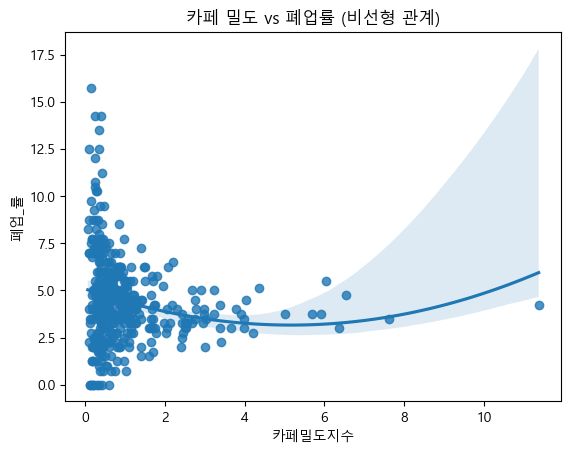

In [34]:
import numpy as np

# 2차 항 추가
df_dong_merged['카페밀도_sq'] = df_dong_merged['카페밀도지수'] ** 2

from sklearn.linear_model import LinearRegression

X_quad = df_dong_merged[['카페밀도지수', '카페밀도_sq']]
y_quad = df_dong_merged['폐업_률']

model_quad = LinearRegression()
model_quad.fit(X_quad, y_quad)

print("coef:", model_quad.coef_)
sns.regplot(
    data=df_dong_merged,
    x='카페밀도지수',
    y='폐업_률',
    order=2   # 💣 핵심
)

plt.title('카페 밀도 vs 폐업률 (비선형 관계)')
plt.show()

3.4
         집객시설_수   카페밀도지수
집객시설_수  1.00000 -0.35225
카페밀도지수 -0.35225  1.00000


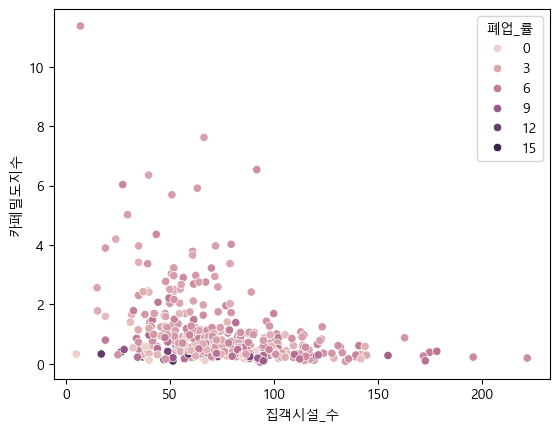

In [35]:
optimal = 3.8

near_optimal = df_dong_merged[
    (df_dong_merged['카페밀도지수'] > optimal - 0.5) &
    (df_dong_merged['카페밀도지수'] < optimal + 0.5)
]

print(near_optimal['폐업_률'].mean())
print(df_dong_merged[['집객시설_수','카페밀도지수']].corr())
sns.scatterplot(
    data=df_dong_merged,
    x='집객시설_수',
    y='카페밀도지수',
    hue='폐업_률'
)
df_dong_merged['다양성지수'] = df_dong_merged['점포_수'] / (df_dong_merged['카페_수'] + 1)

In [36]:
import pickle
pickle.dump(df_dong_merged, open('df_dong_merged.pkl','wb'))
pickle.dump(model, open('rf_model.pkl','wb'))

In [37]:
df_dong_merged['폐업_률'].max()
df_dong_merged[['시군구명','행정동명','폐업_률']].sort_values(by='폐업_률', ascending=False)

,시군구명,행정동명,폐업_률
81,관악구,삼성동,15.75
217,서대문구,북가좌1동,14.25
56,강서구,가양3동,14.25
321,양천구,신월6동,13.50
154,노원구,하계2동,12.50
...,...,...,...
278,성북구,장위3동,0.00
167,도봉구,창4동,0.00
354,용산구,이촌1동,0.00
361,용산구,효창동,0.00


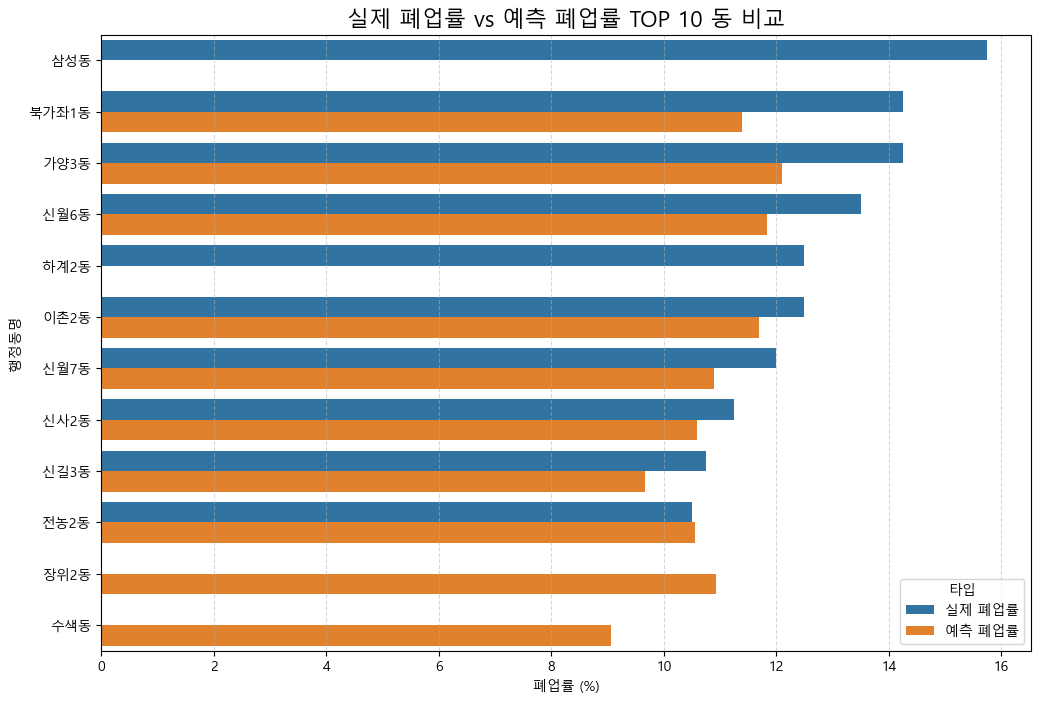

     시군구명   행정동명       폐업_률      타입
81    관악구    삼성동  15.750000  실제 폐업률
217  서대문구  북가좌1동  14.250000  실제 폐업률
56    강서구   가양3동  14.250000  실제 폐업률
321   양천구   신월6동  13.500000  실제 폐업률
154   노원구   하계2동  12.500000  실제 폐업률
355   용산구   이촌2동  12.500000  실제 폐업률
322   양천구   신월7동  12.000000  실제 폐업률
372   은평구   신사2동  11.250000  실제 폐업률
337  영등포구   신길3동  10.750000  실제 폐업률
178  동대문구   전농2동  10.500000  실제 폐업률
56    강서구   가양3동  12.094287  예측 폐업률
321   양천구   신월6동  11.843361  예측 폐업률
355   용산구   이촌2동  11.693898  예측 폐업률
217  서대문구  북가좌1동  11.392177  예측 폐업률
277   성북구   장위2동  10.935621  예측 폐업률
322   양천구   신월7동  10.894137  예측 폐업률
372   은평구   신사2동  10.585651  예측 폐업률
178  동대문구   전농2동  10.557846  예측 폐업률
337  영등포구   신길3동   9.669004  예측 폐업률
370   은평구    수색동   9.058098  예측 폐업률


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 실제 폐업률 TOP 10
actual_top10 = df_dong_merged[['시군구명','행정동명','폐업_률']].sort_values(by='폐업_률', ascending=False).head(10)
actual_top10['타입'] = '실제 폐업률'

# 2. 예측 폐업률 TOP 10
pred_top10 = df_dong_merged[['시군구명','행정동명','예측_폐업률']].sort_values(by='예측_폐업률', ascending=False).head(10)
pred_top10 = pred_top10.rename(columns={'예측_폐업률':'폐업_률'})
pred_top10['타입'] = '예측 폐업률'

# 3. 합치기
compare_top10 = pd.concat([actual_top10, pred_top10])

# 4. 시각화
plt.figure(figsize=(12,8))
sns.barplot(
    data=compare_top10,
    y='행정동명',
    x='폐업_률',
    hue='타입',
    dodge=True
)
plt.title('실제 폐업률 vs 예측 폐업률 TOP 10 동 비교', fontsize=16)
plt.xlabel('폐업률 (%)')
plt.ylabel('행정동명')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

# 5. 비교 테이블
print(compare_top10.sort_values(['타입','폐업_률'], ascending=[True, False]))